# Notebook 00: Data Processing

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from atomic_ocean_waves import clean_data, read_data, mission_specifications, waves, plotting
from atomic_ocean_waves.xarray_helpers import apply_frequency_reduction_ufunc

In [2]:
%load_ext autoreload
%autoreload 2

TODO:
- [x] read in SWIFT data
- [x] read in WSRA data
- [x] read in P3 data
- [x] read in Saildrone data
- [x] read in R/V Ron Brown ship data
- [x] read in Wave Glider data
- [x] read in WW3 data
- [x] read in Riegl data
- [ ] Process SD 1063

In [5]:
# Mission time periods
leg_1_time_start, leg_1_time_end = mission_specifications.leg_1_times
leg_2_time_start, leg_2_time_end = mission_specifications.leg_2_times
leg_1_longitudes, leg_1_latitudes = mission_specifications.leg_1_coordinates
leg_2_longitudes, leg_2_latitudes = mission_specifications.leg_2_coordinates

## SWIFT drifters


In [4]:
swift_ds = read_data.read_swift_directory(directory='../data_input/SWIFT/')

swift_ds.load()

<xarray.Dataset> Size: 16MB
Dimensions:                                                               (
                                                                           id: 6,
                                                                           time: 500,
                                                                           freq: 42,
                                                                           z: 96,
                                                                           zHR: 64)
Coordinates:
  * id                                                                    (id) object 48B ...
  * time                                                                  (time) datetime64[ns] 4kB ...
  * freq                                                                  (freq) float64 336B ...
  * z                                                                     (z) float64 768B ...
  * zHR                                                                   (zHR) float64 512B ...
Data variables: (12/36)
    lat                                                                   (id, time) float64 24kB ...
    lon                                                                   (id, time) float64 24kB ...
    sea_water_temperature                                                 (id, time) float64 24kB ...
    sea_water_salinity                                                    (id, time) float64 24kB ...
    sea_water_temperature_at_depth                                        (id, time) float64 24kB ...
    sea_water_salinity_at_depth                                           (id, time) float64 24kB ...
    ...                                                                    ...
    relative_humidity                                                     (id, time) float64 24kB ...
    east                                                                  (id, z, time) float64 2MB ...
    north                                                                 (id, z, time) float64 2MB ...
    tkedissipationrateHR                                                  (id, zHR, time) float64 2MB ...
    specific_humidity                                                     (id, time) float64 24kB ...
    flag_values_humidity                                                  (id, time) float64 24kB ...
Attributes: (12/22)
    creation_date:        ['13-May-2022 14:33:17' '13-May-2022 14:33:18' '13-...
    creator:              Suneil Iyer (APL-UW), Elizabeth Thompson (NOAA PSL)...
    please_acknowledge::  four investigators above
    institution:          Applied Physics Laboratory at the University of Was...
    contact_email_1:      iyersk@uw.edu
    contact_email_2:      elizabeth.thompson@noaa.gov
    ...                   ...
    missing_data_flag:    -999
    reference1:           Iyer, S., Thomson, J., Thompson, E., & Drushka, K. ...
    reference2:           Iyer, S., Drushka, K., Thompson, E., & Thomson, J.....
    reference3:           Quinn, P.K. et al. (2021). Measurements from the RV...
    reference4:           Stevens, B. et al. (2021). EUREC4A. Earth System Sc...
    reference5:           Thomson, J., Girton, J. B., Jha, R., & Trapani, A. ...

Compute SWIFT bulk wave metrics (peak period, energy-weighted period, MSS, etc.)

In [5]:
# Recompute peak period
swift_ds['peak_period'] = swift_ds['energy'].idxmax('freq')**(-1)

# Calculate energy-weighted wave direction
#TODO: need to use min and max frequency
swift_ds['energy_weighted_a1'] = apply_frequency_reduction_ufunc(
    waves.moment_weighted_mean,
    swift_ds['a1'],
    swift_ds['energy'],
    swift_ds['freq'],
    frequency_dim='freq',
    kwargs=dict(
        n=0,
        # min_frequency=0.05,
        # max_frequency=0.5
    )
)
swift_ds['energy_weighted_b1'] = apply_frequency_reduction_ufunc(
    waves.moment_weighted_mean,
    swift_ds['b1'],
    swift_ds['energy'],
    swift_ds['freq'],
    frequency_dim='freq',
    kwargs=dict(
        n=0,
        # min_frequency=0.05,
        # max_frequency=0.5
    )
)

swift_ds['energy_weighted_direction'] = waves.direction(
    a1=swift_ds['energy_weighted_a1'],
    b1=swift_ds['energy_weighted_b1'],
)

swift_ds['mean_square_slope'] = apply_frequency_reduction_ufunc(
    waves.mean_square_slope,
    swift_ds['energy'],
    swift_ds['freq'],
    frequency_dim='freq',
    kwargs=dict(
        min_frequency=0.05,
        max_frequency=0.5
    )
)

Save a local, processed version of the SWIFT dataset.

In [5]:
swift_ds.to_netcdf('../data_processed/swift.nc')

## Wave Gliders

In [37]:
wg_ds = read_data.read_wave_glider_directory(directory='../data_input/wave_glider/')
wg_ds = clean_data.mask_missing_data(wg_ds, missing_data_flag=float(wg_ds.attrs['missing_data_flag']))

# # Recompute peak period
# wg_ds['peak_period'] = wg_ds['energy'].idxmax('freq')**(-1)

wg_ds

<xarray.Dataset> Size: 538kB
Dimensions:                                                               (
                                                                           id: 2,
                                                                           time: 1564)
Coordinates:
  * id                                                                    (id) object 16B ...
  * time                                                                  (time) datetime64[ns] 13kB ...
Data variables: (12/21)
    lat                                                                   (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    lon                                                                   (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    sea_water_temperature                                                 (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    sea_water_salinity                                                    (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    sea_water_temperature_at_depth                                        (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    sea_water_salinity_at_depth                                           (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    ...                                                                    ...
    specific_humidity                                                     (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    sea_surface_saturation_specific_humidity                              (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    flag_values_airtemp                                                   (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    flag_values_windspd                                                   (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    flag_values_watertemp                                                 (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
    flag_values_salinity                                                  (id, time) float64 25kB dask.array<chunksize=(1, 1390), meta=np.ndarray>
Attributes: (12/22)
    creation_date:        ['13-May-2022 14:33:35' '13-May-2022 14:33:39']
    creator:              Suneil Iyer (APL-UW), Elizabeth Thompson (NOAA PSL)...
    please_acknowledge::  four investigators above
    institution:          Applied Physics Laboratory at the University of Was...
    contact_email_1:      iyersk@uw.edu
    contact_email_2:      elizabeth.thompson@noaa.gov
    ...                   ...
    description:          ['Data collected from Wave Glider 245 during the NO...
    reference1:           Iyer, S., Thomson, J., Thompson, E., & Drushka, K. ...
    reference2:           Iyer, S., Drushka, K., Thompson, E., & Thomson, J.....
    reference3:           Quinn, P.K. et al. (2021). Measurements from the RV...
    reference4:           Stevens, B. et al. (2021). EUREC4A. Earth System Sc...
    reference5:           Thomson, J., Girton, J. B., Jha, R., & Trapani, A. ...

Save a local, processed version of the Wave Glider dataset.

In [7]:
wg_ds.to_netcdf('../data_processed/wave_glider.nc')

## Wide Swath Radar Altimeter

In [8]:
wsra_ds = read_data.read_wsra_directory(directory='../data_input/WSRA/')

wsra_ds

<xarray.Dataset> Size: 83MB
Dimensions:                                (time: 2437, wavenumber_east: 65,
                                            wavenumber_north: 65, obs: 5,
                                            wavelength: 8)
Coordinates:
  * time                                   (time) datetime64[ns] 19kB 2020-01...
  * wavenumber_east                        (wavenumber_east) float32 260B -0....
  * wavenumber_north                       (wavenumber_north) float32 260B -0...
  * obs                                    (obs) timedelta64[ns] 40B -1 days ...
  * wavelength                             (wavelength) float32 32B 366.0 ......
Data variables: (12/28)
    directional_wave_spectrum              (time, wavenumber_east, wavenumber_north) float32 41MB dask.array<chunksize=(1, 65, 65), meta=np.ndarray>
    directional_wave_spectrum_180          (time, wavenumber_east, wavenumber_north) float32 41MB dask.array<chunksize=(1, 65, 65), meta=np.ndarray>
    dominant_to_secondary_partition_angle  (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    dominant_wave_direction                (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    dominant_wave_height                   (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    dominant_wave_wavelength               (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                     ...
    secondary_wave_height                  (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    secondary_wave_wavelength              (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    wind_direction                         (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    wind_speed                             (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
    wave_direction_predicted               (time, wavelength) float32 78kB dask.array<chunksize=(1, 8), meta=np.ndarray>
    swh_correction_ratio                   (time) float32 10kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/16)
    title:                WSRA level 4 data
    history:              ['Wed Aug 12 17:01:59 2020: ncap2 -O -s time=int(ti...
    flight_id:            ['20200117I' '20200119I' '20200123I' '20200124I' '2...
    mission_id:           ATOMIC
    storm_id:             n/a
    date_created:         ['2020-07-30T18:45:57Z' '2020-05-27T18:27:08Z' '202...
    ...                   ...
    activitiy:            ATOMIC
    contact:              Ivan Popstefanija <popstefanija@prosensing.com>
    instrument:           WSRA
    NCO:                  netCDF Operators version 4.9.3 (Homepage = http://n...
    version:              v1.0
    project:              ATOMIC

Save a local, processed version of the WSRA dataset.

In [9]:
wsra_ds.encoding['unlimited_dims'] = None
wsra_ds.to_netcdf('../data_processed/wsra.nc', unlimited_dims=None)

## P3 meteorology

In [10]:
p3_ds = read_data.read_p3_directory('../data_input/P3/')

p3_ds

<xarray.Dataset> Size: 49MB
Dimensions:         (time: 552833)
Coordinates:
  * time            (time) datetime64[ns] 4MB 2020-01-17T14:30:38.425781250 ....
Data variables: (12/20)
    lat             (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    lon             (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    alt             (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    pitch           (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    roll            (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    tas             (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    ...              ...
    Z_CT            (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    Vd_CT           (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    RainRate_Wband  (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    CS_Radar_Corr   (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    MSS_Radar       (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
    U10_sfmr_corr   (time) float32 2MB dask.array<chunksize=(39005,), meta=np.ndarray>
Attributes:
    creation_date:  ['2021-05-05 20:42:56 UTC' '2021-05-05 20:42:57 UTC']
    Conventions:    CF-1.7
    campaign:       EUREC4A
    project:        ATOMIC
    platform:       P3
    product:        Remote-sensing
    contact:        Chris Fairall <Chris.Fairall@noaa.gov>
    version:        v1.1

Save a local, processed version of the P3 dataset.

In [11]:
p3_ds.to_netcdf('../data_processed/p3.nc')

## Saildrone

In [6]:
# TODO: put this inside a module.  Perhaps winds.py?

def wind_direction(u_component: np.ndarray, v_component: np.ndarray):
    """ Calculate wind direction from components.

    Args:
        u_component (np.ndarray): E-W wind component (+E)
        v_component (np.ndarray): N-S wind component (+N)

    Returns:
        np.ndarray: wind direction in meterological convention (+ CW, 0 deg N)
    """
    direction_from_north_going_to = np.arctan2(u_component, v_component)
    return np.mod(180 + np.rad2deg(direction_from_north_going_to), 360)


In [7]:
sd_airsea_ds = read_data.read_saildrone_cdf_file('../data_input/saildrone/ATOMIC_Saildrone-1064_AirSea_2020_v1.1.nc')
sd_spec_ds = read_data.read_saildrone_cdf_file('../data_input/saildrone/SD1064ATOMICpsd.cdf')
sd_bulk_ds = read_data.read_saildrone_asc_file('../data_input/saildrone/SD1064ATOMICwave.asc', data_type='xarray')

# Trim and compute 5-min averages from SD air-sea data.  Note nominal
# sampling is 60s on, 240s off.
airsea_vars = ['UWND_MEAN', 'VWND_MEAN', 'WWND_MEAN', 'WIND_MEASUREMENT_HEIGHT_MEAN', 'WavePeriod']
sd_5min_airsea_ds = (sd_airsea_ds[airsea_vars]
                     .sel(time=slice(leg_1_time_start.tz_localize(None), leg_2_time_end.tz_localize(None)))
                     .resample(time='5min').mean()
                     .rename({'time': 'TIME'}))

# Merge spectral, bulk, and air-sea datasets. Time is rounded time to
# the nearest second to align with remaining indexes.
sd_spec_ds['TIME'] = sd_spec_ds['TIME'].dt.round('1s')
sd_ds = xr.merge(
    [sd_bulk_ds, sd_spec_ds, sd_5min_airsea_ds],
    join='outer',
    # combine_attrs='no_conflicts',
)

# Compute mean horizontal wind speed and direction.
sd_ds['horizontal_wind_speed_mean'] = np.sqrt(sd_ds['UWND_MEAN']**2 + sd_ds['VWND_MEAN']**2)
sd_ds['wind_direction'] = wind_direction(sd_ds['UWND_MEAN'], sd_ds['VWND_MEAN'])

# Zero negative spectral values, which can otherwise cause spurious results.
sd_original_energy_density = sd_ds['EI'].copy()
sd_ds['EI'] = sd_ds['EI'].where(sd_ds['EI'] >= 0, other=0)

# Compute energy-weighted wave period. Note apply_ufunc automatically
# moves core dimensions to the last axes.
sd_ds['energy_period'] = xr.apply_ufunc(
    waves.energy_period,
    sd_ds['EI'],
    sd_ds['FRE'],
    input_core_dims=[['FRE'], ['FRE']],
    output_core_dims=[[]],
    kwargs=dict(
        min_frequency=0.05,
        max_frequency=0.5
    )
)
sd_energy_period_from_raw = xr.apply_ufunc(
    waves.energy_period,
    sd_original_energy_density,
    sd_ds['FRE'],
    input_core_dims=[['FRE'], ['FRE']],
    output_core_dims=[[]],
    kwargs=dict(
        min_frequency=0.05,
        max_frequency=0.5
    )
)

sd_ds

/Users/jacob/Library/CloudStorage/Dropbox/Projects/ATOMIC/atomic-ocean-waves/src/atomic_ocean_waves/waves.py:253: RuntimeWarning: invalid value encountered in divide
  return weighted_moment_n / moment_n


<xarray.Dataset> Size: 4MB
Dimensions:                       (TIME: 8929, FRE: 42)
Coordinates:
  * TIME                          (TIME) datetime64[ns] 71kB 2020-01-13 ... 2...
  * FRE                           (FRE) float64 336B 0.009766 0.02148 ... 0.4902
Data variables: (12/18)
    Julian_DAY                    (TIME) float64 71kB nan nan nan ... nan nan
    LON                           (TIME) float64 71kB nan nan nan ... nan nan
    LAT                           (TIME) float64 71kB nan nan nan ... nan nan
    HS                            (TIME) float64 71kB nan nan nan ... nan nan
    DP                            (TIME) float64 71kB nan nan nan ... nan nan
    DE                            (TIME) float64 71kB nan nan nan ... nan nan
    ...                            ...
    WWND_MEAN                     (TIME) float64 71kB 0.038 0.024 ... 0.03 0.04
    WIND_MEASUREMENT_HEIGHT_MEAN  (TIME) float64 71kB 4.757 4.777 ... 4.952
    WavePeriod                    (TIME) float64 71kB 9.14 nan nan ... nan 10.67
    horizontal_wind_speed_mean    (TIME) float64 71kB 11.65 11.34 ... 10.66
    wind_direction                (TIME) float64 71kB 65.58 67.91 ... 61.25
    energy_period                 (TIME) float64 71kB nan nan nan ... nan nan
Attributes:
    dataset name:   ./SDwave1064_0117_0212.cdf
    time coverage:  17-JAN-2020 00:12 to 12-FEB-2020 23:42
    filename:       SD1064ATOMICwave.asc

Save a local, processed version of the Saildrone dataset.

In [9]:
sd_ds.to_netcdf('../data_processed/saildrone.nc')

## Shipboard observations

In [15]:
ship_1min_nav_met_sea_flux_ds = read_data.read_ship_nav_met_sea_flux_file('../data_input/ship/EUREC4A_ATOMIC_RonBrown_1min_nav_met_sea_20200109-20200212_v1.3.nc')
ship_10min_nav_met_sea_flux_ds = read_data.read_ship_nav_met_sea_flux_file('../data_input/ship/EUREC4A_ATOMIC_RonBrown_10min_nav_met_sea_flux_20200109-20200212_v1.3.nc')
ship_10min_atm_ocean_near_surface_profiles_ds = read_data.read_ship_atm_ocean_near_surface_profiles_file('../data_input/ship/EUREC4A_ATOMIC_RonBrown_atm_ocean_near_surface_profiles_20200109-20200212_v1.1.nc')

In [16]:
# Merge 10-min datasets.
ship_10min_ds = (ship_10min_nav_met_sea_flux_ds
                 .merge(ship_10min_atm_ocean_near_surface_profiles_ds,
                        compat='override'))
ship_10min_ds

<xarray.Dataset> Size: 7MB
Dimensions:                           (time: 5040, depth: 8, height: 15)
Coordinates:
  * time                              (time) datetime64[ns] 40kB 2020-01-09 ....
    lat                               (time) float64 40kB ...
    lon                               (time) float64 40kB ...
    zu                                (time) float64 40kB ...
    ztq                               (time) float64 40kB ...
    zsea                              (time) float64 40kB ...
    zu_ship                           (time) float64 40kB ...
    ztq_ship                          (time) float64 40kB ...
    zsea_ship                         (time) float64 40kB ...
    zair                              (height) float64 120B ...
    zwater                            (depth) float64 64B ...
Dimensions without coordinates: depth, height
Data variables: (12/110)
    RonBrown                          |S1 1B ...
    crs                               float64 8B ...
    rain_instrument                   |S1 1B ...
    shortwave_radiation_instrument_1  |S1 1B ...
    shortwave_radiation_instrument_2  |S1 1B ...
    longwave_radiation_instrument_1   |S1 1B ...
    ...                                ...
    tsea_snk                          (time) float64 40kB ...
    tsea_profile                      (time, depth) float64 323kB ...
    tair_profile                      (time, height) float64 605kB ...
    wspd_profile                      (time, height) float64 605kB ...
    rh_air_profile                    (time, height) float64 605kB ...
    qair_profile                      (time, height) float64 605kB ...
Attributes: (12/33)
    title:                     ATOMIC (Atlantic Tradewind Ocean Atmosphere Me...
    summary:                   The data come from two sources, the NOAA PSL s...
    keywords:                  Earth Science > Atmosphere > Atmospheric Press...
    keywords_vocabulary:       GCMD Earth Science Keywords. Version 8.6
    comment:                   The PSL data (variables without suffix) should...
    instrument:                In Situ Instruments from NOAA PSL and the perm...
    ...                        ...
    cdm_data_type:             Trajectory
    date_created:              2021-03-30T16:13:03Z
    date_modified:             2021-03-30T16:13:03Z
    standard_name_vocabulary:  CF Standard Name Table v41
    ncei_template_version:     NCEI_NetCDF_Trajectory_Template_v2.0
    Conventions:               CF-1.6, ACDD-1.3

Save a local, processed version of the Saildrone dataset.

In [17]:
ship_10min_ds.to_netcdf('../data_processed/ship_10min.nc')

## RIEGL LiDAR

In [18]:
riegl_ds = read_data.read_riegl_file('../data_input/riegl/ATOMIC_2020_riegl.nc')

riegl_ds

<xarray.Dataset> Size: 3MB
Dimensions:                      (frequency: 65, time: 5040)
Coordinates:
  * frequency                    (frequency) float64 520B 0.001953 ... 0.9658
  * time                         (time) datetime64[ns] 40kB 2020-01-09 ... 20...
Data variables:
    energy_density               (frequency, time) float64 3MB ...
    significant_height           (time) float64 40kB ...
    significant_height_wind_sea  (time) float64 40kB ...
    peak_period                  (time) float64 40kB ...
    peak_period_wind_sea         (time) float64 40kB ...
    peak_direction               (time) float64 40kB ...

Compute bulk wave statistics.

In [19]:
# Convert wave direction convention trigonometric to meteorological
riegl_ds['peak_direction']  = waves.trig_to_met(riegl_ds['peak_direction'], degrees=True)

# Compute energy-weighted wave period. Note apply_ufunc automatically
# moves core dimensions to the last axes.
riegl_ds['energy_period'] = xr.apply_ufunc(
    waves.energy_period,
    riegl_ds['energy_density'],
    riegl_ds['frequency'],
    input_core_dims=[['frequency'], ['frequency']],
    output_core_dims=[[]],
    kwargs=dict(
        min_frequency=0.05,
        max_frequency=0.5
    )
)

In [20]:
# TODO: temporary: clean up / incorporate z-score function into src
# TODO: repeat for wind, wave directions

window_size = 6*12  # 10-min data
threshold = 1.5

da = riegl_ds['energy_period']

roll = da.rolling(time=window_size, center=True)
avg = roll.mean()
std = roll.std(ddof=0)
z = (da - avg) / std
z_in_threshold = (z > -threshold) & (z < threshold)

energy_period_screened = riegl_ds['energy_period'].where(z_in_threshold, avg)

# window_size = 6*1  # 10-min data
# roll2 = da.rolling(time=window_size, center=True)
# med = roll2.median()
# mad = roll2.map(lambda x: np.median(np.abs(x - np.median(x))), keep_attrs=True)
# z2 = 0.6745 * (da - med) / mad


/Users/jacob/miniforge3/envs/atomic-ocean-waves/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


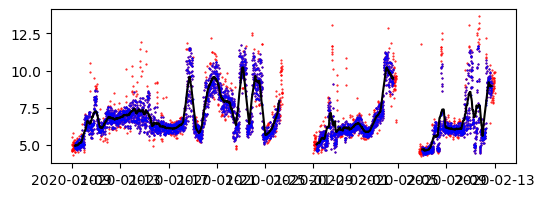

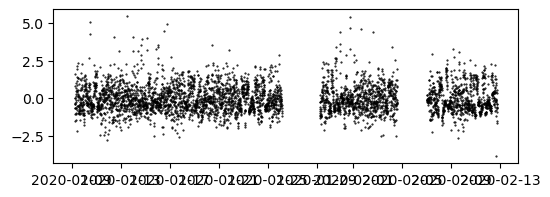

In [ ]:
#TODO: move below
fig, ax = plt.subplots(figsize=(6, 2))
ax.scatter(
    riegl_ds['time'],
    riegl_ds['energy_period'],
    color='red',
    label='Riegl/RHB',
    s=1,
    marker='.',
)
ax.scatter(
    riegl_ds['time'],
    energy_period_screened,
    color='blue',
    label='Riegl/RHB (screened)',
    s=1,
    marker='.',
)
ax.plot(
    avg['time'],
    avg,
    color='black',
    label='riegl (rolling avg)',
)
# ax.scatter(
#     med['time'],
#     med,
#     color='tab:green',
#     label='riegl (rolling median)',
#     s=1,
#     marker='.',
# )

fig, ax = plt.subplots(figsize=(6, 2))
ax.scatter(
    z['time'],
    z,
    color='black',
    label='riegl (rolling avg)',
    s=1,
    marker='.',
)



In [22]:
riegl_ds['energy_period'] = energy_period_screened

Save a local, processed version of the RIEGL dataset.

In [23]:
riegl_ds.to_netcdf('../data_processed/riegl.nc')

## WAVEWATCH III

In [24]:
ww3_ds = read_data.read_ww3_directory(directory='../data_input/WW3/')

ww3_ds

<xarray.Dataset> Size: 28GB
Dimensions:    (time: 480, latitude: 317, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2020-01-01 ... 2020-02-29T21:00:00
  * latitude   (latitude) float32 1kB -78.0 -77.5 -77.0 -76.5 ... 79.0 79.5 80.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables: (12/65)
    MAPSTA     (time, latitude, longitude) int16 219MB dask.array<chunksize=(248, 317, 720), meta=np.ndarray>
    dpt        (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    ucur       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    vcur       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    uwnd       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    vwnd       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    ...         ...
    vabr       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    uubr       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    vubr       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    mssu       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    mssc       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
    mssd       (time, latitude, longitude) float32 438MB dask.array<chunksize=(1, 317, 720), meta=np.ndarray>
Attributes: (12/16)
    WAVEWATCH_III_version_number:     7.01
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SCRIP SCRIPNC SHRD PR3 UQ...
    SIN4 namelist parameter BETAMAX:  1.25
    product_name:                     ['WW3-GLOB-30M_202001.nc' 'WW3-GLOB-30M...
    area:                             Global 0.5 deg wave grid
    latitude_resolution:              0.
    ...                               ...
    easternmost_longitude:            180.
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       ['2020-01-01 00:00:00' '2020-02-01 00:0...
    stop_date:                        ['2020-01-31 21:00:00' '2020-02-29 21:0...

Subset the WAVEWATCH dataset to the time period and spatial domain of ATOMIC Legs 1 and 2.

In [25]:
ww3_ds = ww3_ds.sel(
    time=slice(leg_1_time_start.tz_localize(None), leg_2_time_end.tz_localize(None)),
    longitude=slice(*leg_1_longitudes),
    latitude=slice(*leg_1_latitudes),
)

Compute wind speed magnitude and omnidirectional mean square slope.

In [26]:
ww3_ds['wnd_direction'] = wind_direction(ww3_ds['uwnd'], ww3_ds['vwnd'])

ww3_ds['wnd'] = np.sqrt(ww3_ds['uwnd']**2 + ww3_ds['vwnd']**2)

ww3_ds['mss'] = ww3_ds['mssu'] + ww3_ds['mssc']

Save a local, processed version of the WAVEWATCH III dataset.

In [27]:
ww3_ds.to_netcdf('../data_processed/ww3.nc')

## QC plots

In [25]:
scatter_kwargs = {
    's': 5,
    'marker': '.',
    'edgecolor': 'none',
}

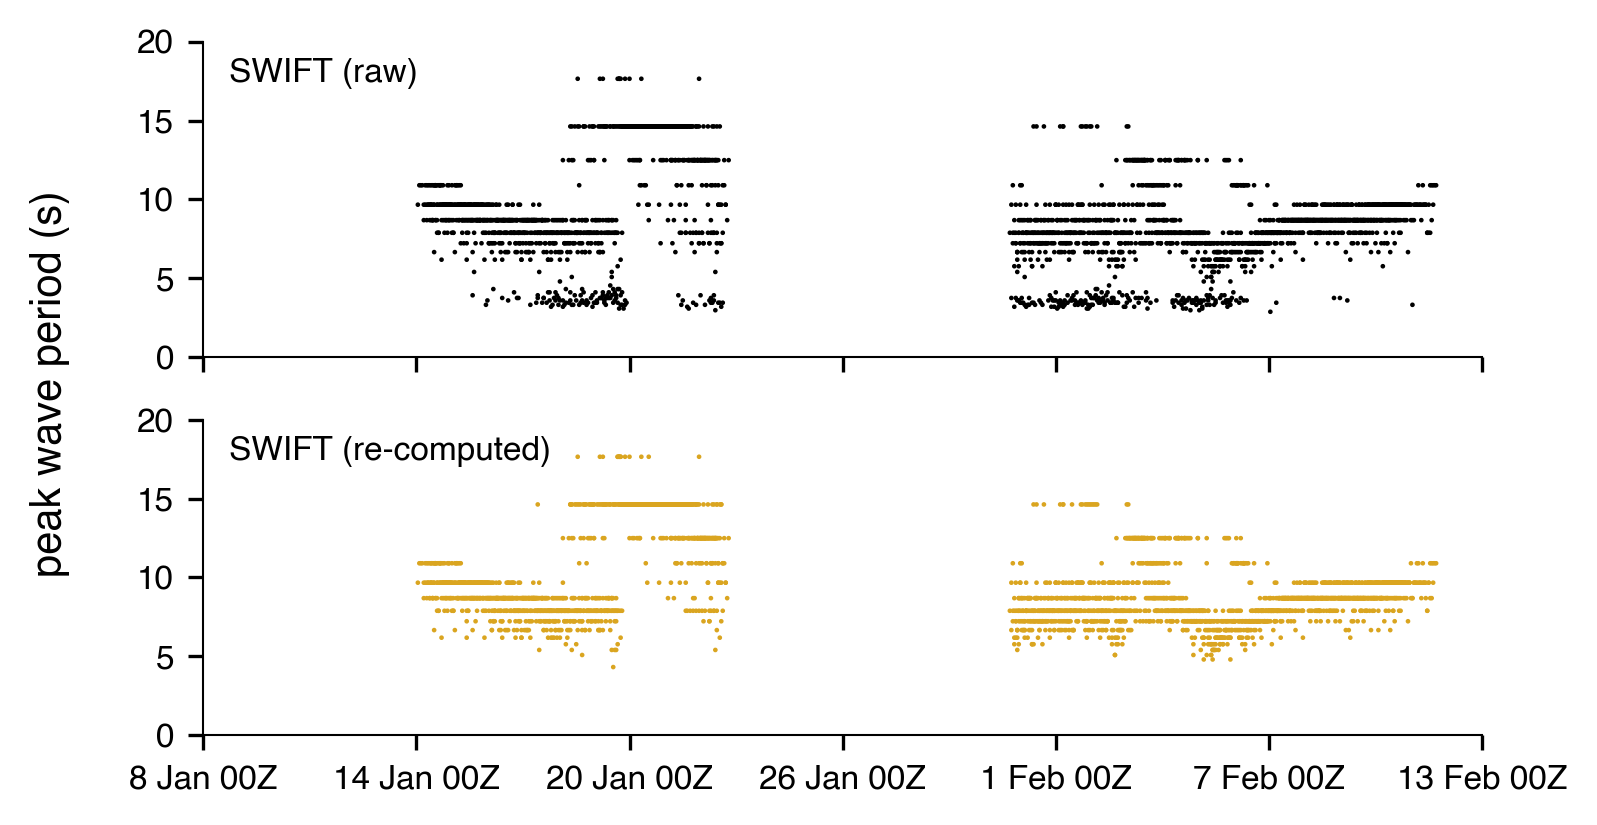

In [ ]:
plot_time_start = pd.Timestamp('2020-01-08T00:00', tz='utc')
plot_time_end = pd.Timestamp('2020-02-13T00:00', tz='utc')

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(plotting.figure_full_width, 3),
    sharex=True,
    sharey=True,
)

# Peak wave period
for swift_id in swift_ds['id']:
    sc1 = axes[0].scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['sea_surface_wave_period_at_variance_spectral_density_maximum'],
        color='k',
        label='SWIFT (raw)',
        **scatter_kwargs,
    )
    sc2 = axes[1].scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['peak_period'],
        color=plotting.swift_color,
        label='SWIFT (re-computed)',
        **scatter_kwargs,
    )

plotting.label_subplot(axes[0], text='SWIFT (raw)', nudge_x=-0.03, fontsize=plotting.small_font_size)
plotting.label_subplot(axes[1], text='SWIFT (re-computed)', nudge_x=-0.03, fontsize=plotting.small_font_size)

for ax in axes:
    plotting.set_time_series_xaxis(ax, plot_time_start, plot_time_end, freq='6d', format='%-d %b %HZ')
    plotting.remove_top_and_right_spines(ax)

axes[0].set_ylim([0, 20])
axes[0].set_yticks(np.linspace(0, 20, 5))
fig.supylabel(
    'peak wave period (s)',
    fontsize=plotting.normal_font_size
)
# fig.savefig('swift_peak_period_comparison_recomputed.png')


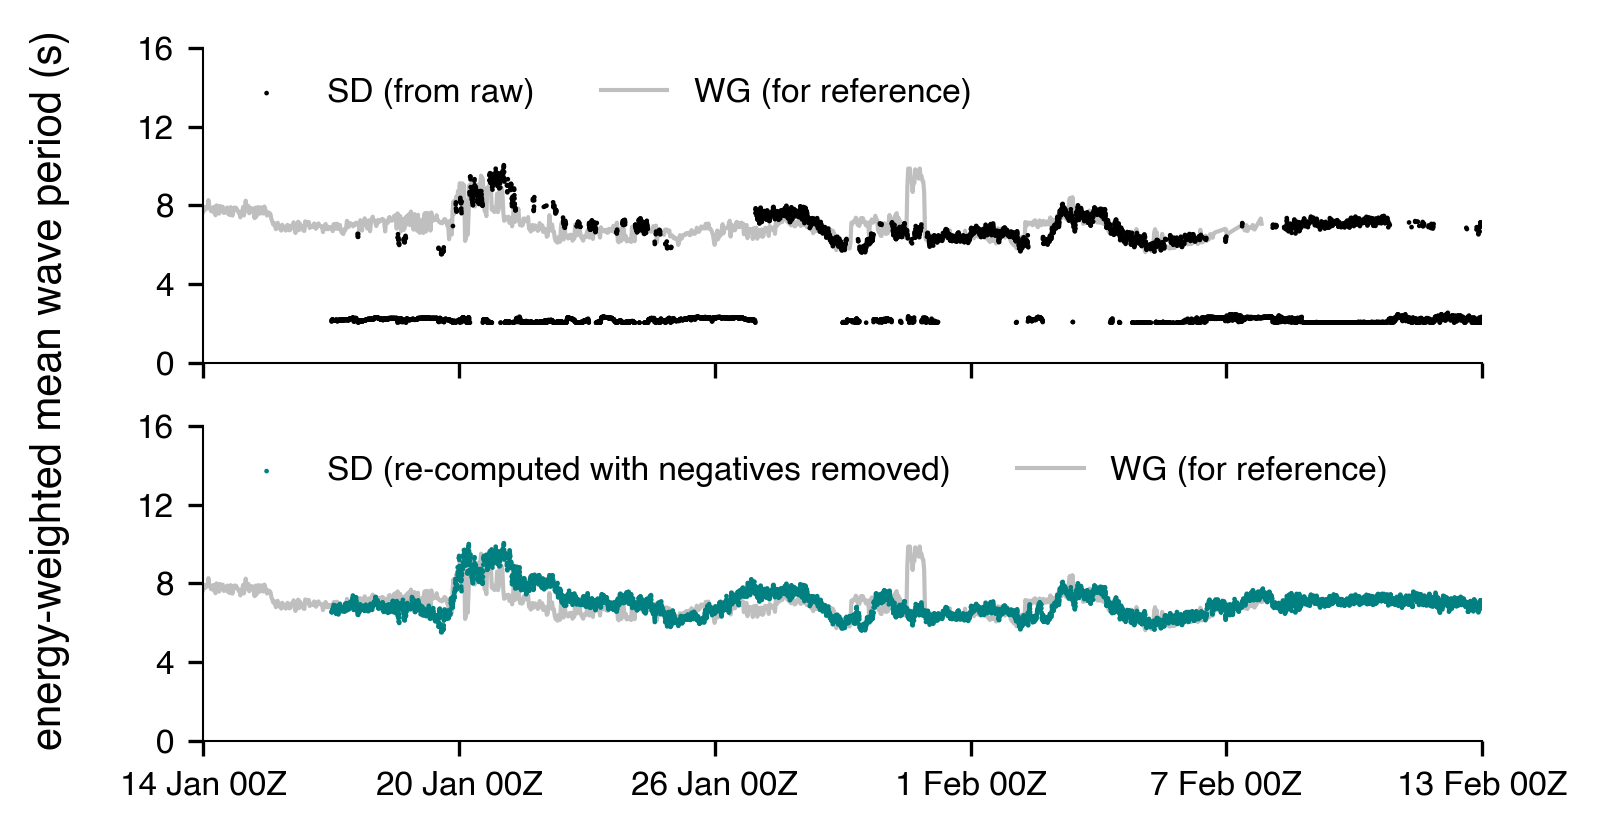

In [ ]:
plot_time_start = pd.Timestamp('2020-01-14T00:00', tz='utc')
plot_time_end = pd.Timestamp('2020-02-13T00:00', tz='utc')

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(plotting.figure_full_width, 3),
    sharex=True,
    sharey=True,
)
axes[0].scatter(
    sd_ds['TIME'],
    sd_energy_period_from_raw,
    color='k',
    label='SD (from raw)',
    **scatter_kwargs,
)
axes[0].plot(
    wg_ds.isel(id=0)['time'],
    wg_ds.isel(id=0)['sea_surface_wave_mean_period'],
    label='WG (for reference)',
    color='k',
    linewidth=1,
    alpha=0.25,
    zorder=0,
    # **scatter_kwargs,
)
axes[1].scatter(
    sd_ds['TIME'],
    sd_ds['energy_period'],
    color=plotting.sd_color,
    label='SD (re-computed with negatives removed)',
    **scatter_kwargs,
)
axes[1].plot(
    wg_ds.isel(id=0)['time'],
    wg_ds.isel(id=0)['sea_surface_wave_mean_period'],
    label='WG (for reference)',
    color='k',
    linewidth=1,
    alpha=0.25,
    zorder=0,
    # **scatter_kwargs,
)

for ax in axes:
    plotting.set_time_series_xaxis(ax, plot_time_start, plot_time_end, freq='6d', format='%-d %b %HZ')
    plotting.remove_top_and_right_spines(ax)

axes[0].legend(frameon=False, loc='upper left', ncols=2)
axes[1].legend(frameon=False, loc='upper left', ncols=2)
axes[0].set_ylim([0, 16])
axes[0].set_yticks(np.linspace(0, 16, 5))
fig.supylabel(
    'energy-weighted mean wave period (s)',
    fontsize=plotting.normal_font_size
)
# fig.savefig('wave_glider_mean_period_comparison_negative_energy.png')